SQA with Path Integral Quantum Monte Carlo (PIMC) using Suzuki-Trotter transformation

Demonstrated to solve vertex cover problem

We approximate the quantum annealing process by using PIMC with Suzuki-Trotter decomposition to represent the quantum partition
function as a classical system, where the imaginary-time dimension is discretized into 
slices (i.e replicas or Trotter layers)



In [66]:
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
import numba
import math

In [67]:
# Generate spins[p][n] -> d +1 suzuki-trotter transformation which takes into
# account multiple trotter replicas of the system to model quantum tunnelling
# through barriers. 
# slice p - 1 needs to match slice 0 - periodic boundary condition. 
def generate_spins():
    N = 100
    k = 10
    spin_matrix = np.zeros((k, N), dtype=np.int64)
    for i in range(k):
        for j in range(N):
            spin_matrix[i][j] = np.random.choice(np.array([1, 0], dtype=np.int64))

    return spin_matrix



spin_matrix = generate_spins()
# print("Spin Matrix:")
# print(spin_matrix)


In [68]:
# adjacency matrix of size NxN depicting undirected graph G = (V, E)
# 0 represents no connection, 1 represents a connection. 
# diagonal is all zereos. 


@numba.njit
def build_adjacency_matrix():
    p = 0.5
    N = 100
    adjacency_matrix = np.zeros((N, N), dtype=np.int64)
    for i in range(N):
        for j in range(i + 1, N):
            if np.random.rand() < p and i != j:
                # Only add an edge if i and j are not the same node
                # and the random condition is met
                adjacency_matrix[i, j] = 1
                adjacency_matrix[j, i] = 1
    return adjacency_matrix

adjacency_matrix = build_adjacency_matrix()



#print("Adjacency Matrix:")
#print(adjacency_matrix)

In [69]:
# xalpha is the kth slice in the spin matrix.
def get_delta_ha(adjacency_matrix, xalpha, v, A):
    uncovered_neighbors = 0
    for u in range(len(xalpha)):
        if adjacency_matrix[v][u] == 1 and xalpha[u] == 0:
            uncovered_neighbors += 1
    
    if xalpha[v] == 1:  # was 0, just got flipped to 1
        return -A * uncovered_neighbors
    else:               # was 1, just got flipped to 0
        return +A * uncovered_neighbors
    

In [70]:
# J_perp = -(P · T / 2) · ln(tanh(Γ / (P · T)))
def get_j_perp(gamma, T):
    p = 10
    j_perp = -0.5 * p * T * math.log(math.tanh(gamma / (p * T)))
    return j_perp

In [71]:
# note: [k][v] is the new spin value for vertex v in slice k.
# delta_coupling = -J_perp * (spins[k-1][v] + spins[k+1][v]) * (new_val - old_val)
def get_delta_coupling(gamma, j_perp, spins, v, k):
    P  = spins.shape[0]
    new_spin = spins[k][v]
    old_spin = 1 - spins[k][v]
    delta_coupling = -j_perp * (spins[(k - 1) % P][v] + spins[(k + 1) % P][v]) * (new_spin - old_spin)
    return delta_coupling
    

In [72]:
def calc_delta_e(adjacency_matrix, spin_matrix, A, B, gamma, k, v, T):
    h_a = get_delta_ha(adjacency_matrix, spin_matrix[k], v, A) / spin_matrix.shape[0]
    # if spin got flipped from 0 to 1 we add 1 to the energy, if it got flipped from 1 to 0 we subtract 1 from the energy.
    h_b = (B if spin_matrix[k][v] == 1 else -B) 
    delta_coupling = get_delta_coupling(gamma, get_j_perp(gamma, T), spin_matrix, v, k)
    delta_e = h_a + h_b + delta_coupling
    return delta_e
   
    

In [73]:
# In a Feynman path integral, particle traverses all paths simulataneously.
# We use the suzuki-trotter transformation to model this by creating multiple replicas of the system.
def annealing(spin_matrix, adjacency_matrix, A, B, beta, gamma_start, gamma_end, steps):
    P = spin_matrix.shape[0] # number of slices
    N = spin_matrix.shape[1] # number of vertices
    for step in range(steps):
        # anneal gamma linearly from gamma_start to gamma_end
        gamma = gamma_start * (1 - step / steps) + gamma_end * (step / steps)
        # pick a slice and node and flip the spin at random. 
        k = np.random.randint(0, P)
        v = np.random.randint(0, N)
        spin_matrix[k][v] = 1 - spin_matrix[k][v]
        # get delta_e for this flip. 
        delta_e = calc_delta_e(adjacency_matrix, spin_matrix, A, B, gamma, k, v)
        # if delta_e is negative we accept the flip, if delta_e is positive we accept the flip with probability e^(-beta * delta_e)
        if delta_e > 0 and np.random.rand() >= math.exp(-beta * delta_e):
            # flip back the spin if we reject the flip. 
            spin_matrix[k][v] = 1 - spin_matrix[k][v]
        # print the first 5 slices of the spin matrix for the first 5 steps 
        if step < 5:
            print(f"Step {step + 1}:")
            print(spin_matrix[:5])


    return spin_matrix


In [74]:
def verify_cover(solution, adjacency_matrix):
    N = len(solution)
    uncovered = 0
    for i in range(N):
        for j in range(i+1, N):
            if adjacency_matrix[i][j] == 1 and solution[i] == 0 and solution[j] == 0:
                uncovered += 1
    cover_size = np.sum(solution)
    print(f"Cover size: {cover_size}")
    print(f"Uncovered edges: {uncovered}")



In [75]:
# def annealing_with_tracking(spin_matrix, adjacency_matrix, A, B, beta, gamma_start, gamma_end, steps, track_every=1000):
#     P = spin_matrix.shape[0]
#     N = spin_matrix.shape[1]
#     T = 1 / beta
    
#     ones_counts = []
#     step_numbers = []
    
#     for step in range(steps):
#         gamma = gamma_start * (1 - step / steps) + gamma_end * (step / steps)
        
#         k = np.random.randint(0, P)
#         v = np.random.randint(0, N)
#         spin_matrix[k][v] = 1 - spin_matrix[k][v]
        
#         delta_e = calc_delta_e(adjacency_matrix, spin_matrix, A, B, gamma, k, v, T)
        
#         if delta_e > 0 and np.random.rand() >= math.exp(-delta_e / T):
#             spin_matrix[k][v] = 1 - spin_matrix[k][v]
        
#         if step == steps/2:
#             print(f"Step {step + 1}:")
#             verify_cover(spin_matrix[0], adjacency_matrix)
        
#         if step % track_every == 0:
#             ones_counts.append(np.sum(spin_matrix))
#             step_numbers.append(step)


             
    
#     # plt.style.use('science')
#     plt.figure(figsize=(10, 5))
#     plt.plot(step_numbers, ones_counts)
#     plt.axhline(y=P * N, color='r', linestyle='--', label=f'All 1s ({P * N})')
#     plt.xlabel('Step')
#     plt.ylabel('Total 1s across all slices')
#     plt.title('Spin saturation over annealing')
#     plt.legend()
#     plt.show()
    
#     return spin_matrix

In [76]:
# def annealing_with_tracking_stepwise(spin_matrix, adjacency_matrix, A, B, T, gamma_start, gamma_end, num_stages, sweeps_per_stage, alpha_A, alpha_B, track_every=1000):
#     P = spin_matrix.shape[0]
#     N = spin_matrix.shape[1]
    
#     ones_counts = []
#     step_numbers = []
    
#     gamma_values = np.linspace(gamma_start, gamma_end, num_stages)
#     total_step = 0
    
#     for gamma in gamma_values:
#         j_perp = get_j_perp(gamma, T)
#         A_eff = alpha_A * j_perp
#         B_eff = alpha_B * j_perp
#         for sweep in range(sweeps_per_stage):
#             k = np.random.randint(0, P)
#             v = np.random.randint(0, N)
#             spin_matrix[k][v] = 1 - spin_matrix[k][v]
            
#             delta_e = calc_delta_e(adjacency_matrix, spin_matrix, A_eff, B_eff, gamma, k, v, T)
            
#             if delta_e > 0 and np.random.rand() >= math.exp(-delta_e / T):
#                 spin_matrix[k][v] = 1 - spin_matrix[k][v]
            
#             if total_step % track_every == 0:
#                 ones_counts.append(np.sum(spin_matrix))
#                 step_numbers.append(total_step)
            
#             total_step += 1

#             if total_step == (num_stages * sweeps_per_stage) // 2:
#                 print(f"Step {total_step}:")
#                 verify_cover(spin_matrix[0], adjacency_matrix)
    
#     plt.figure(figsize=(10, 5))
#     plt.plot(step_numbers, ones_counts)
#     plt.axhline(y=P * N, color='r', linestyle='--', label=f'All 1s ({P * N})')
#     plt.xlabel('Step')
#     plt.ylabel('Total 1s across all slices')
#     plt.title('Spin saturation over annealing')
#     plt.legend()
#     plt.show()
    
#     return spin_matrix

In [77]:
def annealing_with_tracking_2(spin_matrix, adjacency_matrix, A, B, beta, gamma_start, gamma_end, steps, track_every=1000):
    P = spin_matrix.shape[0]
    N = spin_matrix.shape[1]
    T = 1 / beta
    
    ones_counts = []
    uncovered_counts = []
    step_numbers = []
    
    for step in range(steps):
        gamma = gamma_start * (1 - step / steps) + gamma_end * (step / steps)
        
        k = np.random.randint(0, P)
        v = np.random.randint(0, N)
        spin_matrix[k][v] = 1 - spin_matrix[k][v]
        
        delta_e = calc_delta_e(adjacency_matrix, spin_matrix, A, B, gamma, k, v, T)
        
        if delta_e > 0 and np.random.rand() >= math.exp(-delta_e / T):
            spin_matrix[k][v] = 1 - spin_matrix[k][v]
        
        if step == steps/2:
            print(f"Step {step + 1}:")
            verify_cover(spin_matrix[0], adjacency_matrix)
        
        if step % track_every == 0:
            ones_counts.append(np.sum(spin_matrix))
            step_numbers.append(step)
            uncovered = 0
            for i in range(N):
                for j in range(i + 1, N):
                    if adjacency_matrix[i][j] == 1 and spin_matrix[0][i] == 0 and spin_matrix[0][j] == 0:
                        uncovered += 1
                    
                        
            uncovered_counts.append(uncovered)
            # print uncovered edges at each 5th step
            if step % (5 * track_every) == 0:
                print(f"Step {step + 1}: Uncovered edges in slice 0 = {uncovered}")
            
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    ax1.plot(step_numbers, ones_counts, color='blue', label='Total 1s across all slices')
    ax1.axhline(y=P * N, color='r', linestyle='--', label=f'All 1s ({P * N})')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Total 1s across all slices', color='blue')
    
    ax2 = ax1.twinx()
    ax2.plot(step_numbers, uncovered_counts, color='orange', label='Uncovered edges (slice 0)')
    ax2.set_ylabel('Uncovered edges (slice 0)', color='orange')
    
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    fig.suptitle('Spin saturation and edge coverage over annealing')
    plt.tight_layout()
    plt.show()
    
    return spin_matrix

Step 1: Uncovered edges in slice 0 = 463
Step 5001: Uncovered edges in slice 0 = 68
Step 10001: Uncovered edges in slice 0 = 56
Step 15001: Uncovered edges in slice 0 = 56
Step 20001: Uncovered edges in slice 0 = 55
Step 25001: Uncovered edges in slice 0 = 55
Step 30001: Uncovered edges in slice 0 = 55
Step 35001: Uncovered edges in slice 0 = 56
Step 40001: Uncovered edges in slice 0 = 45
Step 45001: Uncovered edges in slice 0 = 44
Step 50001: Uncovered edges in slice 0 = 51
Step 55001: Uncovered edges in slice 0 = 44
Step 60001: Uncovered edges in slice 0 = 52
Step 65001: Uncovered edges in slice 0 = 52
Step 70001: Uncovered edges in slice 0 = 52
Step 75001: Uncovered edges in slice 0 = 44
Step 80001: Uncovered edges in slice 0 = 45
Step 85001: Uncovered edges in slice 0 = 60
Step 90001: Uncovered edges in slice 0 = 59
Step 95001: Uncovered edges in slice 0 = 44
Step 100001:
Cover size: 78
Uncovered edges: 51
Step 100001: Uncovered edges in slice 0 = 51
Step 105001: Uncovered edges in

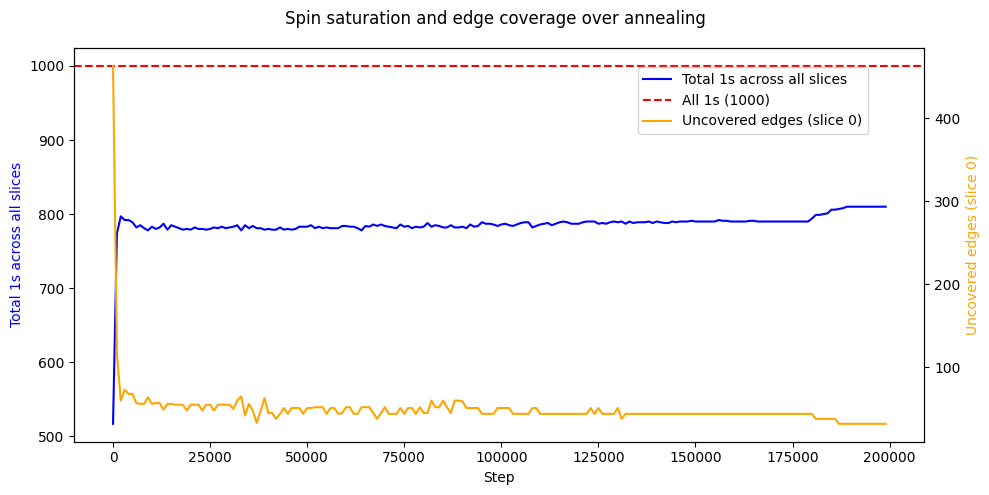

J_perp at start: 0.0915884368592407
J_perp at middle: 0.6794764984426096
J_perp at end: 15.536523579385701
Cover size: 81
Uncovered edges: 32


In [ ]:
T = 0.5
beta = 1 / T
A = 20      # must dominate B heavily — uncovered edge penalty
B = 10      # cost per node in cover
gamma_start = 10.0   # strong transverse field initially
gamma_end = 0.01    # nearly zero at the end
steps = 200000       # enough sweeps to converge

num_stages = 100
sweeps_per_stage = 2000
alpha_A = 3.0
alpha_B = 1.0


initial_spin_matrix = spin_matrix.copy()
final_spin_matrix = annealing_with_tracking_2(initial_spin_matrix, adjacency_matrix, A, B, beta, gamma_start, gamma_end, steps)
# final_spin_matrix = annealing_with_tracking_stepwise(initial_spin_matrix,
# adjacency_matrix, A, B, T, gamma_start, gamma_end, num_stages, sweeps_per_stage, alpha_A, alpha_B)
# print j_perp at the start, middle and end of annealing to verify that it is decreasing.
print(f"J_perp at start: {get_j_perp(gamma_start, T)}")
print(f"J_perp at middle: {get_j_perp((gamma_start + gamma_end) / 2, T)}")
print(f"J_perp at end: {get_j_perp(gamma_end, T)}")
# print first few linkes of initial and final spin matrices to verify that they
# are different.
verify_cover(final_spin_matrix[0], adjacency_matrix)
# print("Initial Spin Matrix (first 5 slices):")
# print(initial_spin_matrix[:5])
# print("\nFinal Spin Matrix (first 5 slices):")
# print(final_spin_matrix[:5])
